### Imports and Constants

In [1]:
import sys
sys.path.append('../')

from gam_rs_utils.utils import *
from method_scripts.results import Results

In [53]:
SUPPORT_SET_METRICS = [Metrics.inverse_IoU, Metrics.euclidean_distance, Metrics.inverse_cosine_similarity]
PREDICTION_METRICS = ['accuracy', 'logistic']
LOGIT_METRICS = [Metrics.compute_logit_variance, Metrics.compute_logit_pairwise_distance]

def collate_datasets_results():
    all_datasets_results = {}
    for dn in DATASET_NAMES:
        runs = list()
        runs_paths = os.listdir(f"../results/{dn}/method_results")
        runs_paths.sort()
        for fn in runs_paths:
            result = Results.load_result(f"../results/{dn}/method_results/{fn}")
            runs.append(result.to_dataframe_row())
        all_datasets_results[dn] = pd.concat(runs, axis=0, ignore_index=True)
    return all_datasets_results

def populate_datasets_results(all_datasets_results, n_samples):
    feature_metrics = []
    # do hamming, model count, 

    for dn, df in all_datasets_results.items():
        new_cols = defaultdict(list)
        for i, row in df.iterrows():
            # load rashomon set for this run
            w_rset = row['w_rset'][:100,:]
            w_opt = row['w_opt']
            l0 = row['l0']
            l2 = 0.001 # l2 = row['l2']
            method_type = row['method_type']

            # load dataset used for this run
            dataset = Results.load_dataset(f"../results/{dn}", {'l0': l0, 'l2': l2})
            bin_X = dataset['bin_X']
            y = dataset['y']
            cum_header = dataset['cum_header']

            if method_type == MethodType.SWAPPING:
                data = pd.read_csv(f"../datasets/{dn}.csv")
                w_rset_expanded = []
                for w in w_rset:
                    sparse_X, sparse_header = utils.binary_to_one_hot(data.iloc[:,:-1], w, cum_header)
                    header_object = ModelUtils.get_header_object(cum_header)
                    sparse_header_object = ModelUtils.get_header_object(sparse_header)
                    
                    new_w = []
                    i = 0
                    weights = w[w.nonzero()[0]]
                    for feat in sparse_header:
                        if len(feat.split('<')) > 2 or feat == 'intercept':
                            new_w.append(weights[i])
                            i += 1
                        else:
                            new_w.append(0.0)
                    new_w = np.array(new_w)
                    w_rset_expanded.append(ModelUtils.expand_w(new_w, sparse_header_object, header_object))
                w_rset = np.vstack(w_rset_expanded)
                row['w_rset'] = w_rset

            # compute diversity metrics on the support set
            for metric in SUPPORT_SET_METRICS:
                average_diversity = Metrics.average_pairwise_diversity(w_rset, metric, limit=n_samples)
                new_cols[metric.__name__].append(average_diversity)
            
            # compute diversity metrics on the predicted values
            for metric in PREDICTION_METRICS:
                losses, opt_loss = ModelUtils.get_loss(bin_X, y, w_rset, loss_type=metric, w_opt=w_opt, l2=l2)
                new_cols[metric].append(losses)
                new_cols[metric + '_opt'].append(opt_loss)

            # compute logit metrics
            logits = bin_X @ w_rset.T
            # compute diversity metrics on the logits
            for metric in LOGIT_METRICS:
                new_cols[metric.__name__].append(metric(logits))

            # compute feature-specific metrics
        # add new_cols to df
        for key, value in new_cols.items():
            df[key] = value

In [ ]:
    # for dname, df in all_datasets_results.items():
    #     print(dname)
    #     accuracy, logistic, hamming, iou, euclidean, cosine, feature_to_vi = [], [], [], [], [], [], []
    #     model_count, headers = [], []
    #     feature_to_shape_diversities = []
    #     feature_to_shape_differences = []
    #     logit_variances = []
    #     logit_distances = []

    #     path = f"../datasets/{dname}.csv"
    #     X, y, header, new_header, sample_p = DatasetUtils.get_binned_dataset(path, df.iloc[0]['n_estimators'])
    #     for i, row in df.iterrows():
    #         w_rset = row["w_rset"]
    #         w_opt = row["w_opt"]
    #         predictions = row["predictions"]
    #         l2 = 0.001
            
    #         model_count.append((w_rset.shape[0], (w_rset.shape[0], w_rset.shape[0])))
    #         if w_rset.shape[0] == 0:
    #             accuracy.append((0, (0, 0)))
    #             logistic.append((0, (0, 0)))
    #             hamming.append((0, (0, 0)))
    #             iou.append((0, (0, 0)))
    #             euclidean.append((0, (0, 0)))
    #             cosine.append((0, (0, 0)))
    #             logit_variances.append((0, (0, 0)))
    #             logit_distances.append((0, (0, 0)))
    #             feature_to_vi.append([])
    #             feature_to_shape_diversities.append({feature: [] for feature in new_header[1:]})
    #             feature_to_shape_differences.append({feature: [] for feature in new_header[1:]})
    #             headers.append(new_header)
    #             continue

    #         print(f"\t{i}: {w_rset.shape[0]}")
    #         if w_rset.shape[0] > n_samples: 
    #             w_rset = w_rset[:n_samples]
    #             predictions = predictions[:n_samples]
    #             print(f"\ttruncated to {n_samples}")

    #         accuracy.append(get_mean_and_ci(ModelUtils.get_loss(X, y, w_rset, loss_type="accuracy")[0]))
    #         logistic.append(get_mean_and_ci(ModelUtils.get_loss(X, y, w_rset, loss_type="logistic", l2=l2, sample_p=sample_p)[0]))
    #         hamming.append(average_pairwise_diversity(predictions.T, hamming_distance, limit=n_samples))

    #         logits = X @ w_rset.T
    #         logit_variances.append(compute_logit_variance(logits))
    #         logit_distances.append(average_pairwise_diversity(logits, euclidean_distance, limit=n_samples))

    #         iou.append(average_pairwise_diversity(w_rset, inverse_IoU, limit=n_samples))
    #         euclidean.append(average_pairwise_diversity(w_rset, euclidean_distance, limit=n_samples))
    #         cosine.append(average_pairwise_diversity(w_rset, inverse_cosine_similarity, limit=n_samples))
    #         headers.append(new_header)

    #         feature_to_vi.append(get_variable_importance(X, w_rset[:, 1:], np.array(new_header[1:]), True))
            
    #         # get feature to indices
    #         feature_to_indices = defaultdict(list)
    #         feature_to_widths = defaultdict(list)
    #         feature_ranges = get_feature_ranges(np.array(new_header[1:]))
    #         for feature, ranges in feature_ranges.items():
    #             for r in ranges:
    #                 if len(r) == 1:
    #                     feature_to_widths[feature].append(r[0])
    #                 else:
    #                     feature_to_widths[feature].append(r[1] - r[0])
    #         for i, col in enumerate(new_header[1:]):
    #             match = re.search(r'([a-zA-Z]+)', col)
    #             if match:
    #                 feature = match.group(1)
    #                 feature_to_indices[feature].append(i)
            
    #         feature_to_shape_diversity = defaultdict(list)
    #         feature_to_shape_difference = defaultdict(list)
    #         for feature, indices in feature_to_indices.items():
    #             indices = np.array(indices)
    #             average_X_row = X[:, indices]
    #             feature_to_shape_diversity[feature].append(average_pairwise_diversity(w_rset[:, indices], shape_diversity, limit=n_samples, X=average_X_row))
    #             feature_to_shape_difference[feature].append(average_pairwise_diversity(w_rset[:, indices], shape_difference, limit=n_samples, X=feature_to_widths[feature]))
    #         feature_to_shape_diversities.append(feature_to_shape_diversity)
    #         feature_to_shape_differences.append(feature_to_shape_difference)
        
    #     df['accuracy'] = accuracy
    #     df['logistic'] = logistic
    #     df['hamming'] = hamming
    #     df['iou'] = iou
    #     df['euclidean'] = euclidean
    #     df['cosine'] = cosine
    #     df['model_count'] = model_count
    #     df['header'] = headers
    #     df['feature_to_vi'] = feature_to_vi
    #     df['feature_to_shape_diversities'] = feature_to_shape_diversities
    #     df['feature_to_shape_differences'] = feature_to_shape_differences
    #     df['logit_variances'] = logit_variances
    #     df['logit_distances'] = logit_distances

### Compute All Metrics

In [3]:
n_samples = 100
all_datasets_results = collate_datasets_results()

In [4]:
populate_datasets_results(all_datasets_results, n_samples)

loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.p

In [6]:
with open(f'all_datasets_results.pkl', 'wb') as f:
    pickle.dump(all_datasets_results, f)

### Get Plotting Functions

In [ ]:
w_rset = all_datasets_results['bank'].iloc[12]['w_rset'][:100,:]

dataset = Results.load_dataset(f"../results/bank", {'l0': 0.001, 'l2': 0.001})
bin_X = dataset['bin_X']
y = dataset['y']
cum_header = dataset['cum_header']

data = pd.read_csv(f"../datasets/bank.csv")
w_rset_expanded = []
for w in w_rset:
    sparse_X, sparse_header = utils.binary_to_one_hot(data.iloc[:,:-1], w, cum_header)
    header_object = ModelUtils.get_header_object(cum_header)
    sparse_header_object = ModelUtils.get_header_object(sparse_header)
    new_w = []
    i = 0
    weights = w[w.nonzero()[0]]
    for feat in sparse_header:
        if len(feat.split('<')) > 2 or feat == 'intercept':
            new_w.append(weights[i])
            i += 1
        else:
            new_w.append(0.0)
    new_w = np.array(new_w)
    w_rset_expanded.append(ModelUtils.expand_w(new_w, sparse_header_object, header_object))

w_rset = np.vstack(w_rset_expanded)

loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
[5.958892382275383]
[5.958892382275383, 0.0]
[5.958892382275383, 0.0, 0.7499198336617002]
[5.958892382275383, 0.0, 0.7499198336617002, 0.0]
[5.958892382275383, 0.0, 0.7499198336617002, 0.0, 0.801253747614171]
[5.958892382275383, 0.0, 0.7499198336617002, 0.0, 0.801253747614171, -2.2740780098732074]
[5.958892382275383, 0.0, 0.7499198336617002, 0.0, 0.801253747614171, -2.2740780098732074, 0.0]
[5.958892382275383, 0.0, 0.7499198336617002, 0.0, 0.801253747614171, -2.2740780098732074, 0.0, -1.5296600843707784]
[5.958892382275383, 0.0, 0.7499198336617002, 0.0, 0.801253747614171, -2.2740780098732074, 0.0, -1.5296600843707784, -0.9019329333216792]
[5.958892382275383, 0.0, 0.7499198336617002, 0.0, 0.801253747614171, -2.2740780098732074, 0.0, -1.5296600843707784, -0.9019329333216792, -1.0399511668332884]
[5.958892382275383, 0.0, 0.7499198336617002, 0.0, 0.801253747614171, -2.2740780098732074, 0.0, -1.5296600843707784, -0.9019329333216792,

In [88]:
with open(f'all_datasets_results.pkl', 'rb') as f:
    all_datasets_results = pickle.load(f)
    
def get_label(row):
    if row['method_type'] == MethodType.SWAPPING:
        return row['method_type'].value
    elif row['method_type'] == MethodType.ELLIPSOID:
        label = f"{row['method_type'].value} {row['sampling']}"
        if row['distance_metric']:
            label += f" ({row['distance_metric']})"
        return label
    elif row['method_type'] == MethodType.MCMC:
        return f"{row['method_type'].value} {row['proposal_function']}, sample {row['sample_from_rset']}"
    else:
        return row['method_type'].value

want_to_plot = [
    'ellipsoid surface (euclidean)',
    'mcmc random, sample 20.0',
    'mcmc correlation_swap, sample 20.0',
    'mcmc random_swap, sample 20.0',
    'swapping',
]
for dn, df in all_datasets_results.items():
    for i, row in df.iterrows():
        if want_to_plot and get_label(row) not in want_to_plot:
            df.drop(i, inplace=True)

In [89]:
feature_to_shape_metrics = ['feature_to_shape_differences', 'feature_to_shape_diversities']

def show_loss_distributions(all_datasets_results, dn, loss_type):
    df = all_datasets_results[dn]
    plotter = MultiPlotter(title=f"{dn} - {loss_type} Loss Distributions")
    for i, row in df.iterrows():
        losses = row[loss_type]
        opt_loss = row[loss_type + '_opt']
        plotter.add_distribution(losses, get_label(row), opt_loss)
    plotter.plot_distributions()

def get_bar_plot(all_datasets_results, metric):
    plotter = MultiPlotter(title=f"{metric} Bar Plot")
    for dname, df in all_datasets_results.items():
        labels = [get_label(row) for _, row in df.iterrows()]
        list_of_mean_and_cis = df[metric].to_list()
        if metric in PREDICTION_METRICS:
            list_of_mean_and_cis = [Metrics.get_mean_and_ci(distribution) for distribution in list_of_mean_and_cis]
        plotter.add_bar(list_of_mean_and_cis, dname, labels)
    fig = plotter.plot_bar_charts()
    return fig

def get_gam(all_datasets_results, dname, n_samples=100):
    plotter = MultiPlotter(title=f"GAM Shape Functions")
    df = all_datasets_results[dname]
    for i, row in df.iterrows():
        dataset = Results.load_dataset(f"../results/{dname}", {'l0': 0.001, 'l2': 0.001})
        plotter.add_shape_function(np.array(dataset['bin_header'][1:]), row['w_rset'][:n_samples, 1:], get_label(row))
    fig = plotter.plot_shape_functions()
    return fig

def get_variable_importance(all_datasets_results, dname):
    df = all_datasets_results[dname]
    plotter = MultiPlotter(title=f"Variable Importance Distributions")
    for i, row in df.iterrows():
        plotter.add_variable_importance_distribution(row['feature_to_vi'], row['method'])
    fig = plotter.plot_variable_importance_distributions()
    return fig

def get_model_reliance(all_datasets_results, dname):
    df = all_datasets_results[dname]
    
    plotter = MultiPlotter(title=f"Model Reliance for {dname}")
    for i, row in df.iterrows():
        plotter.add_model_reliance(row['feature_to_vi'], row['method'])
    fig = plotter.plot_model_reliance_violin_plots()
    return fig

def get_feature_to_shape_diversity(all_dataset_results, dname, metric):
    df = all_dataset_results[dname]

    plotter = MultiPlotter(title=f"{metric} for {dname}")
    for i, row in df.iterrows():
        plotter.add_shape_diversity(row[metric], row['method'])
    fig = plotter.plot_shape_diversity()
    return fig

def show_swapping_percentages(all_dataset_results, dname):
    df = all_dataset_results[dname]
    collated_swapping_percentages = []
    for i, row in df.iterrows():
        if row['method'].startswith("swapping"):
            collated_swapping_percentages.append(row['swapping_percentages'])

    swapping_methods = [m for m in methods if m.startswith("swapping")]
    plt.bar(swapping_methods, [np.average(p) for p in collated_swapping_percentages])
    plt.xticks(rotation=45)
    plt.title(f"Swapping Percentages")
    plt.tight_layout()
    plt.show()

    for sm, p in zip(swapping_methods, collated_swapping_percentages):
        plt.hist(p, bins=30)
        plt.title(f"{sm} - Swapping Percentages")
        plt.tight_layout()
        plt.show()

def get_table_results(all_dataset_results):
    details = ['dataset', 'method']
    metrics = ['accuracy', 'inverse_IoU', 'euclidean_distance', 'inverse_cosine_similarity'] #'compute_logit_variance', 'compute_logit_pairwise_distance', 'hamming']
    # feature_based_metrics = ['feature_to_shape_differences', 'feature_to_shape_diversities']

    combined_df = pd.DataFrame()
    for dname, df in all_dataset_results.items():
        df['method'] = [get_label(row) for _, row in df.iterrows()]
        df = df[details + metrics].copy()
        df[metrics] = df[metrics].applymap(lambda v: round(v[0], 3))
        combined_df = pd.concat([combined_df, df], ignore_index=True)
    return combined_df

### Visualizations

25


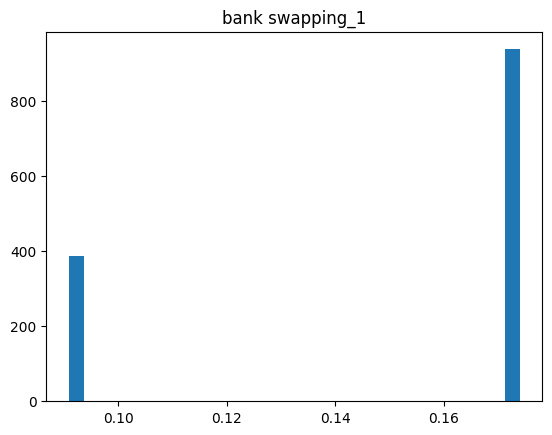

25


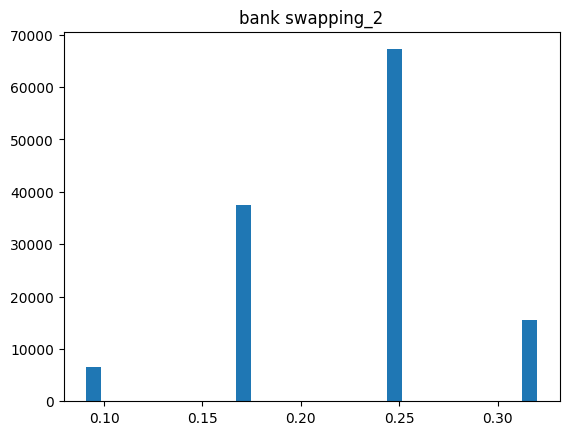

25


KeyboardInterrupt: 

In [ ]:
for dataset, df in all_datasets_results.items():
    for i, row in df.iterrows():
        if not row['method'].startswith('swapping'):
            continue
        # distribution = []
        # w_rset = row['w_rset']
        # for w in w_rset:
        #     distribution.extend(list(w.nonzero()[0]))

        # plt.title(f"{dataset} {row['method']}")
        # plt.hist(distribution, bins=30)
        # plt.show()

        iou_distribution = []
        w_rset = row['w_rset']
        print(w_rset.shape[1])
        for i in range(w_rset.shape[0]):
            for j in range(i + 1, w_rset.shape[0]):
                iou_distribution.append(inverse_IoU(w_rset[i], w_rset[j]))
        plt.title(f"{dataset} {row['method']}")
        plt.hist(iou_distribution, bins=30)
        plt.show()

In [70]:
all_datasets_results['bank']

,method_type,dataset,n_estimators,n_support_set,n_samples,w_rset,w_opt,rset_bound,runtime,l0,...,distance_metric,inverse_IoU,euclidean_distance,inverse_cosine_similarity,accuracy,accuracy_opt,logistic,logistic_opt,compute_logit_variance,compute_logit_pairwise_distance
0,MethodType.ELLIPSOID,bank,50,20,1000,"[[-1.3251886619183726, 0.0, 0.0, 0.0, 0.0, 0.0...","[-0.3335835739102942, 0.0, 0.0, 0.0, 0.0, 0.0,...",0.256566,7.290230,0.001,...,None,"(0.0, [0.0, 0.0])","(34.19760351258696, [34.19760351258696, 34.197...","(0.1730788671504659, [0.1730788671504659, 0.17...","[0.09466932094669321, 0.09732360097323602, 0.0...",0.09666,"[0.2538789871740084, 0.2551984136193397, 0.254...",0.244347,"(2.599784158398328, [1.8202515400575656, 3.596...","(18.299946620405557, [0.0, 52.0643181066941])"
1,MethodType.ELLIPSOID,bank,50,20,1000,"[[3.0205004010319048, 0.0, 0.0, 0.0, 0.0, 0.0,...","[-0.33263391264209796, 0.0, 0.0, 0.0, 0.0, 0.0...",0.256566,8.210859,0.001,...,euclidean,"(0.0, [0.0, 0.0])","(32.62480658804959, [32.62480658804959, 32.624...","(0.16145633670661977, [0.16145633670661977, 0....","[0.10196859101968592, 0.09798717097987171, 0.0...",0.09666,"[0.2553292829577626, 0.2557257330754393, 0.254...",0.244334,"(2.74329629893043, [1.7499416610697933, 3.5996...","(18.833951957627235, [0.0, 53.50016626046996])"
2,MethodType.ELLIPSOID,bank,50,20,1000,"[[-1.3409257368987038, 0.0, 0.0, 0.0, 0.0, 0.0...","[-0.3326875546050956, 0.0, 0.0, 0.0, 0.0, 0.0,...",0.256566,7.262756,0.001,...,mahalanobis,"(0.0, [0.0, 0.0])","(31.53063508301349, [31.53063508301349, 31.530...","(0.15387731860840378, [0.15387731860840378, 0....","[0.09555408095554081, 0.09710241097102411, 0.0...",0.09666,"[0.2526529458598829, 0.2539001530805224, 0.253...",0.244333,"(2.735921998423208, [1.8910395803446363, 3.633...","(18.822473163262963, [0.0, 53.67277993471812])"
3,MethodType.ELLIPSOID,bank,50,20,1000,"[[-0.9952773734661885, 0.0, 0.0, 0.0, 0.0, 0.0...","[-0.3325434413142905, 0.0, 0.0, 0.0, 0.0, 0.0,...",0.256566,45.462566,0.001,...,predictive,"(0.0, [0.0, 0.0])","(37.205316511495816, [37.205316511495816, 37.2...","(0.20123428078361422, [0.20123428078361422, 0....","[0.09688122096881222, 0.09599646095996461, 0.0...",0.09666,"[0.2550932798386916, 0.2534077884779863, 0.255...",0.244332,"(2.669645924227893, [1.7126564064395133, 3.677...","(18.456073673332877, [0.0, 53.21401791519007])"
4,MethodType.ELLIPSOID,bank,50,20,1000,"[[-0.8854056027394793, 0.0, 0.0, 0.0, 0.0, 0.0...","[-0.33270222108545255, 0.0, 0.0, 0.0, 0.0, 0.0...",0.256566,7.256401,0.001,...,None,"(0.0, [0.0, 0.0])","(34.35226681042571, [34.35226681042571, 34.352...","(0.1673967912397431, [0.1673967912397431, 0.16...","[0.10174740101747401, 0.0948905109489051, 0.09...",0.09666,"[0.2551085127280069, 0.2562429768898391, 0.253...",0.244331,"(2.7590981897181375, [1.9612140545909105, 3.58...","(18.948591094935693, [0.0, 53.6925321418914])"
5,MethodType.ELLIPSOID,bank,50,20,1000,"[[-0.15477724638428678, 0.0, 0.0, 0.0, 0.0, 0....","[-0.33323823025138594, 0.0, 0.0, 0.0, 0.0, 0.0...",0.256566,8.306473,0.001,...,euclidean,"(0.0, [0.0, 0.0])","(35.89735019317509, [35.89735019317509, 35.897...","(0.17537182588861802, [0.17537182588861802, 0....","[0.09798717097987171, 0.09798717097987171, 0.0...",0.09666,"[0.25546028035919605, 0.2560819272915495, 0.25...",0.244331,"(2.7482402569665783, [1.9483329883460252, 3.76...","(18.81458254231609, [0.0, 53.92576969961518])"
6,MethodType.ELLIPSOID,bank,50,20,1000,"[[-1.549445546896261, 0.0, 0.0, 0.0, 0.0, 0.0,...","[-0.3335098806813915, 0.0, 0.0, 0.0, 0.0, 0.0,...",0.256566,7.300603,0.001,...,mahalanobis,"(0.0, [0.0, 0.0])","(32.92804681404759, [32.92804681404759, 32.928...","(0.15940127101568832, [0.15940127101568832, 0....","[0.09688122096881222, 0.0982083609820836, 0.09...",0.09666,"[0.2554677795056205, 0.25533961049999726, 0.25...",0.244337,"(2.7443959063728642, [1.9263414430724746, 3.65...","(18.863376527944844, [0.0, 53.40662236004501])"
7,MethodType.ELLIPSOID,bank,50,20,1000,"[[1.04115

yooo
yooo
yooo
yooo
yooo
yooo


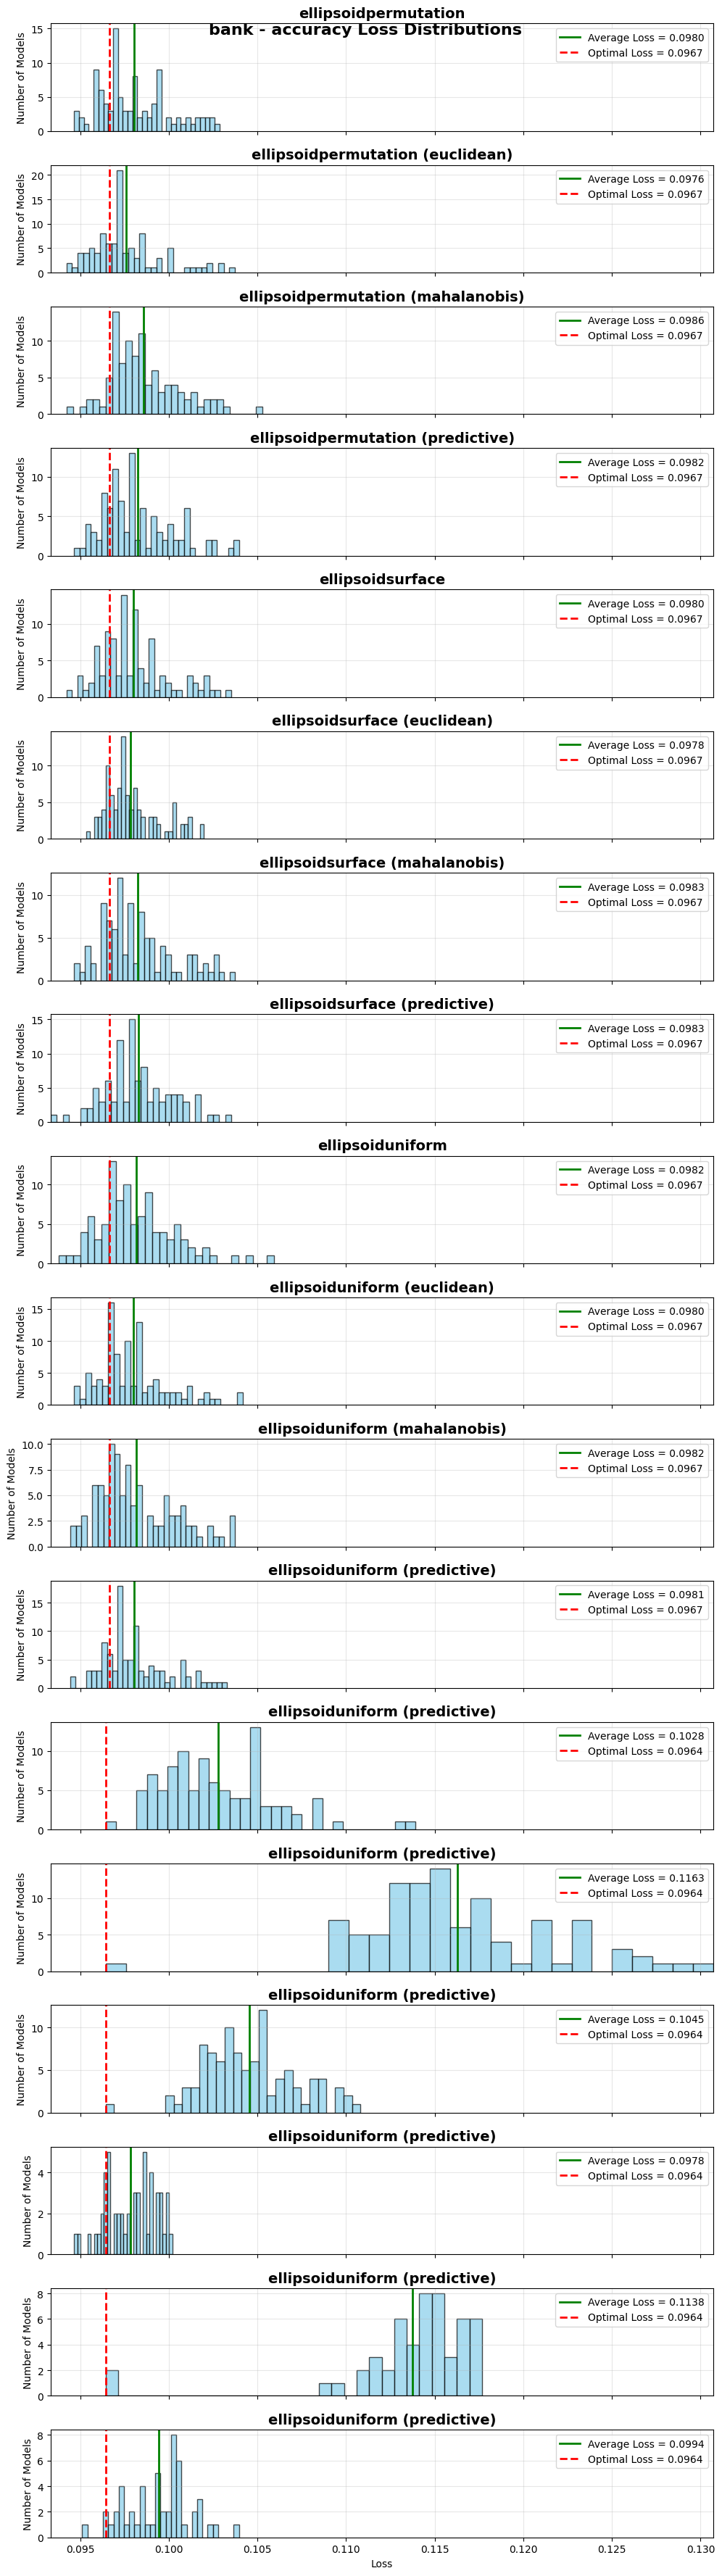

In [9]:
show_loss_distributions(all_datasets_results, "bank", "accuracy")

In [50]:
all_datasets_results['bank'].columns

Index(['method_type', 'dataset', 'n_estimators', 'n_support_set', 'n_samples',
       'w_rset', 'w_opt', 'rset_bound', 'runtime', 'l0', 'l2', 'm', 'sampling',
       'distance_metric', 'proposal_function', 'sigma2', 'sample_from_rset',
       'beta', 'inverse_IoU', 'euclidean_distance',
       'inverse_cosine_similarity', 'accuracy', 'accuracy_opt', 'logistic',
       'logistic_opt', 'compute_logit_variance',
       'compute_logit_pairwise_distance'],
      dtype='object')

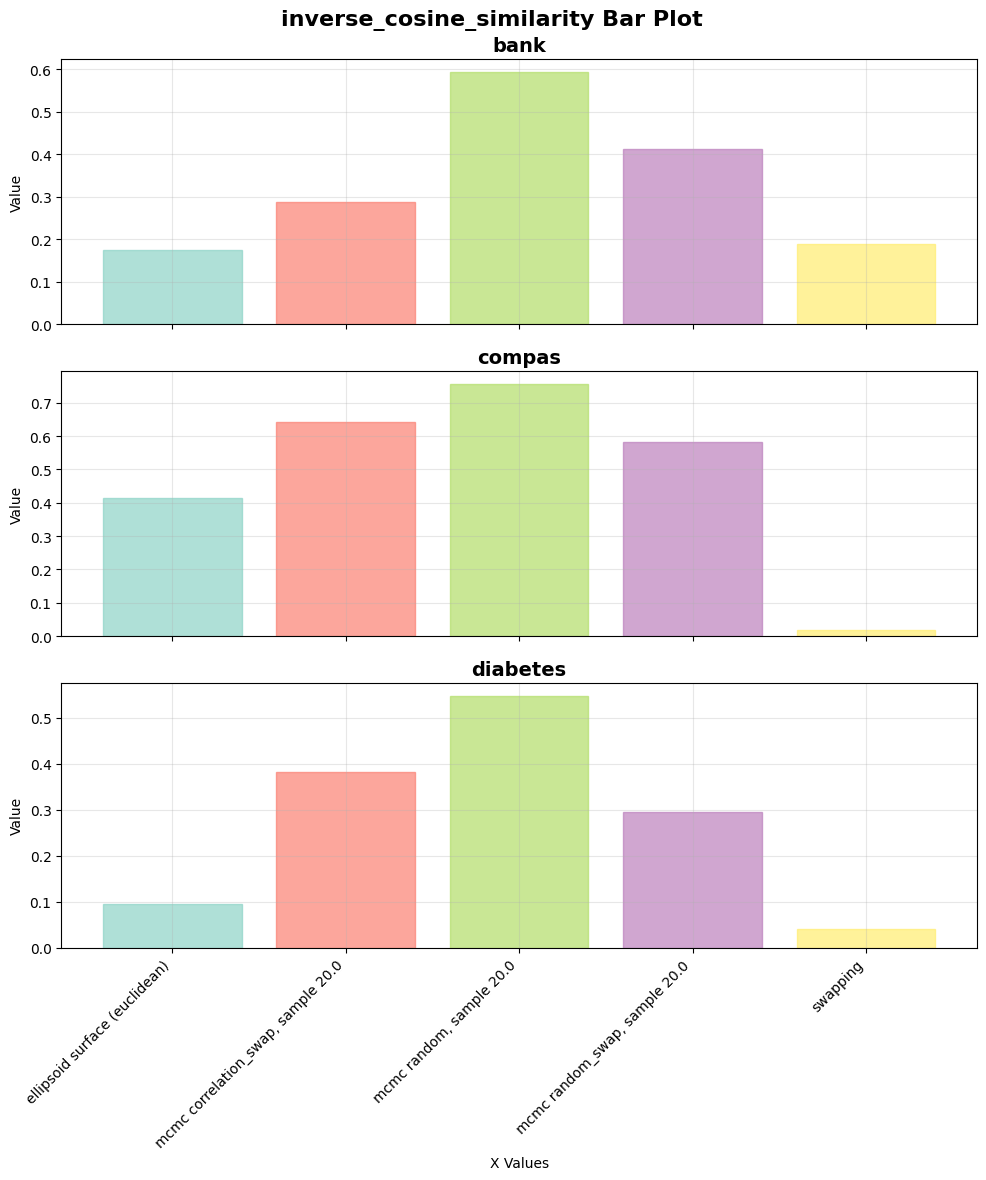

In [93]:
bar_metrics = ['accuracy', 'logistic', 'hamming', 'inverse_IoU', 'euclidean_distance', 'inverse_cosine_similarity', 'logit_variances', 'logit_distances']
bar_plot = get_bar_plot(all_datasets_results, 'inverse_cosine_similarity')

loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl


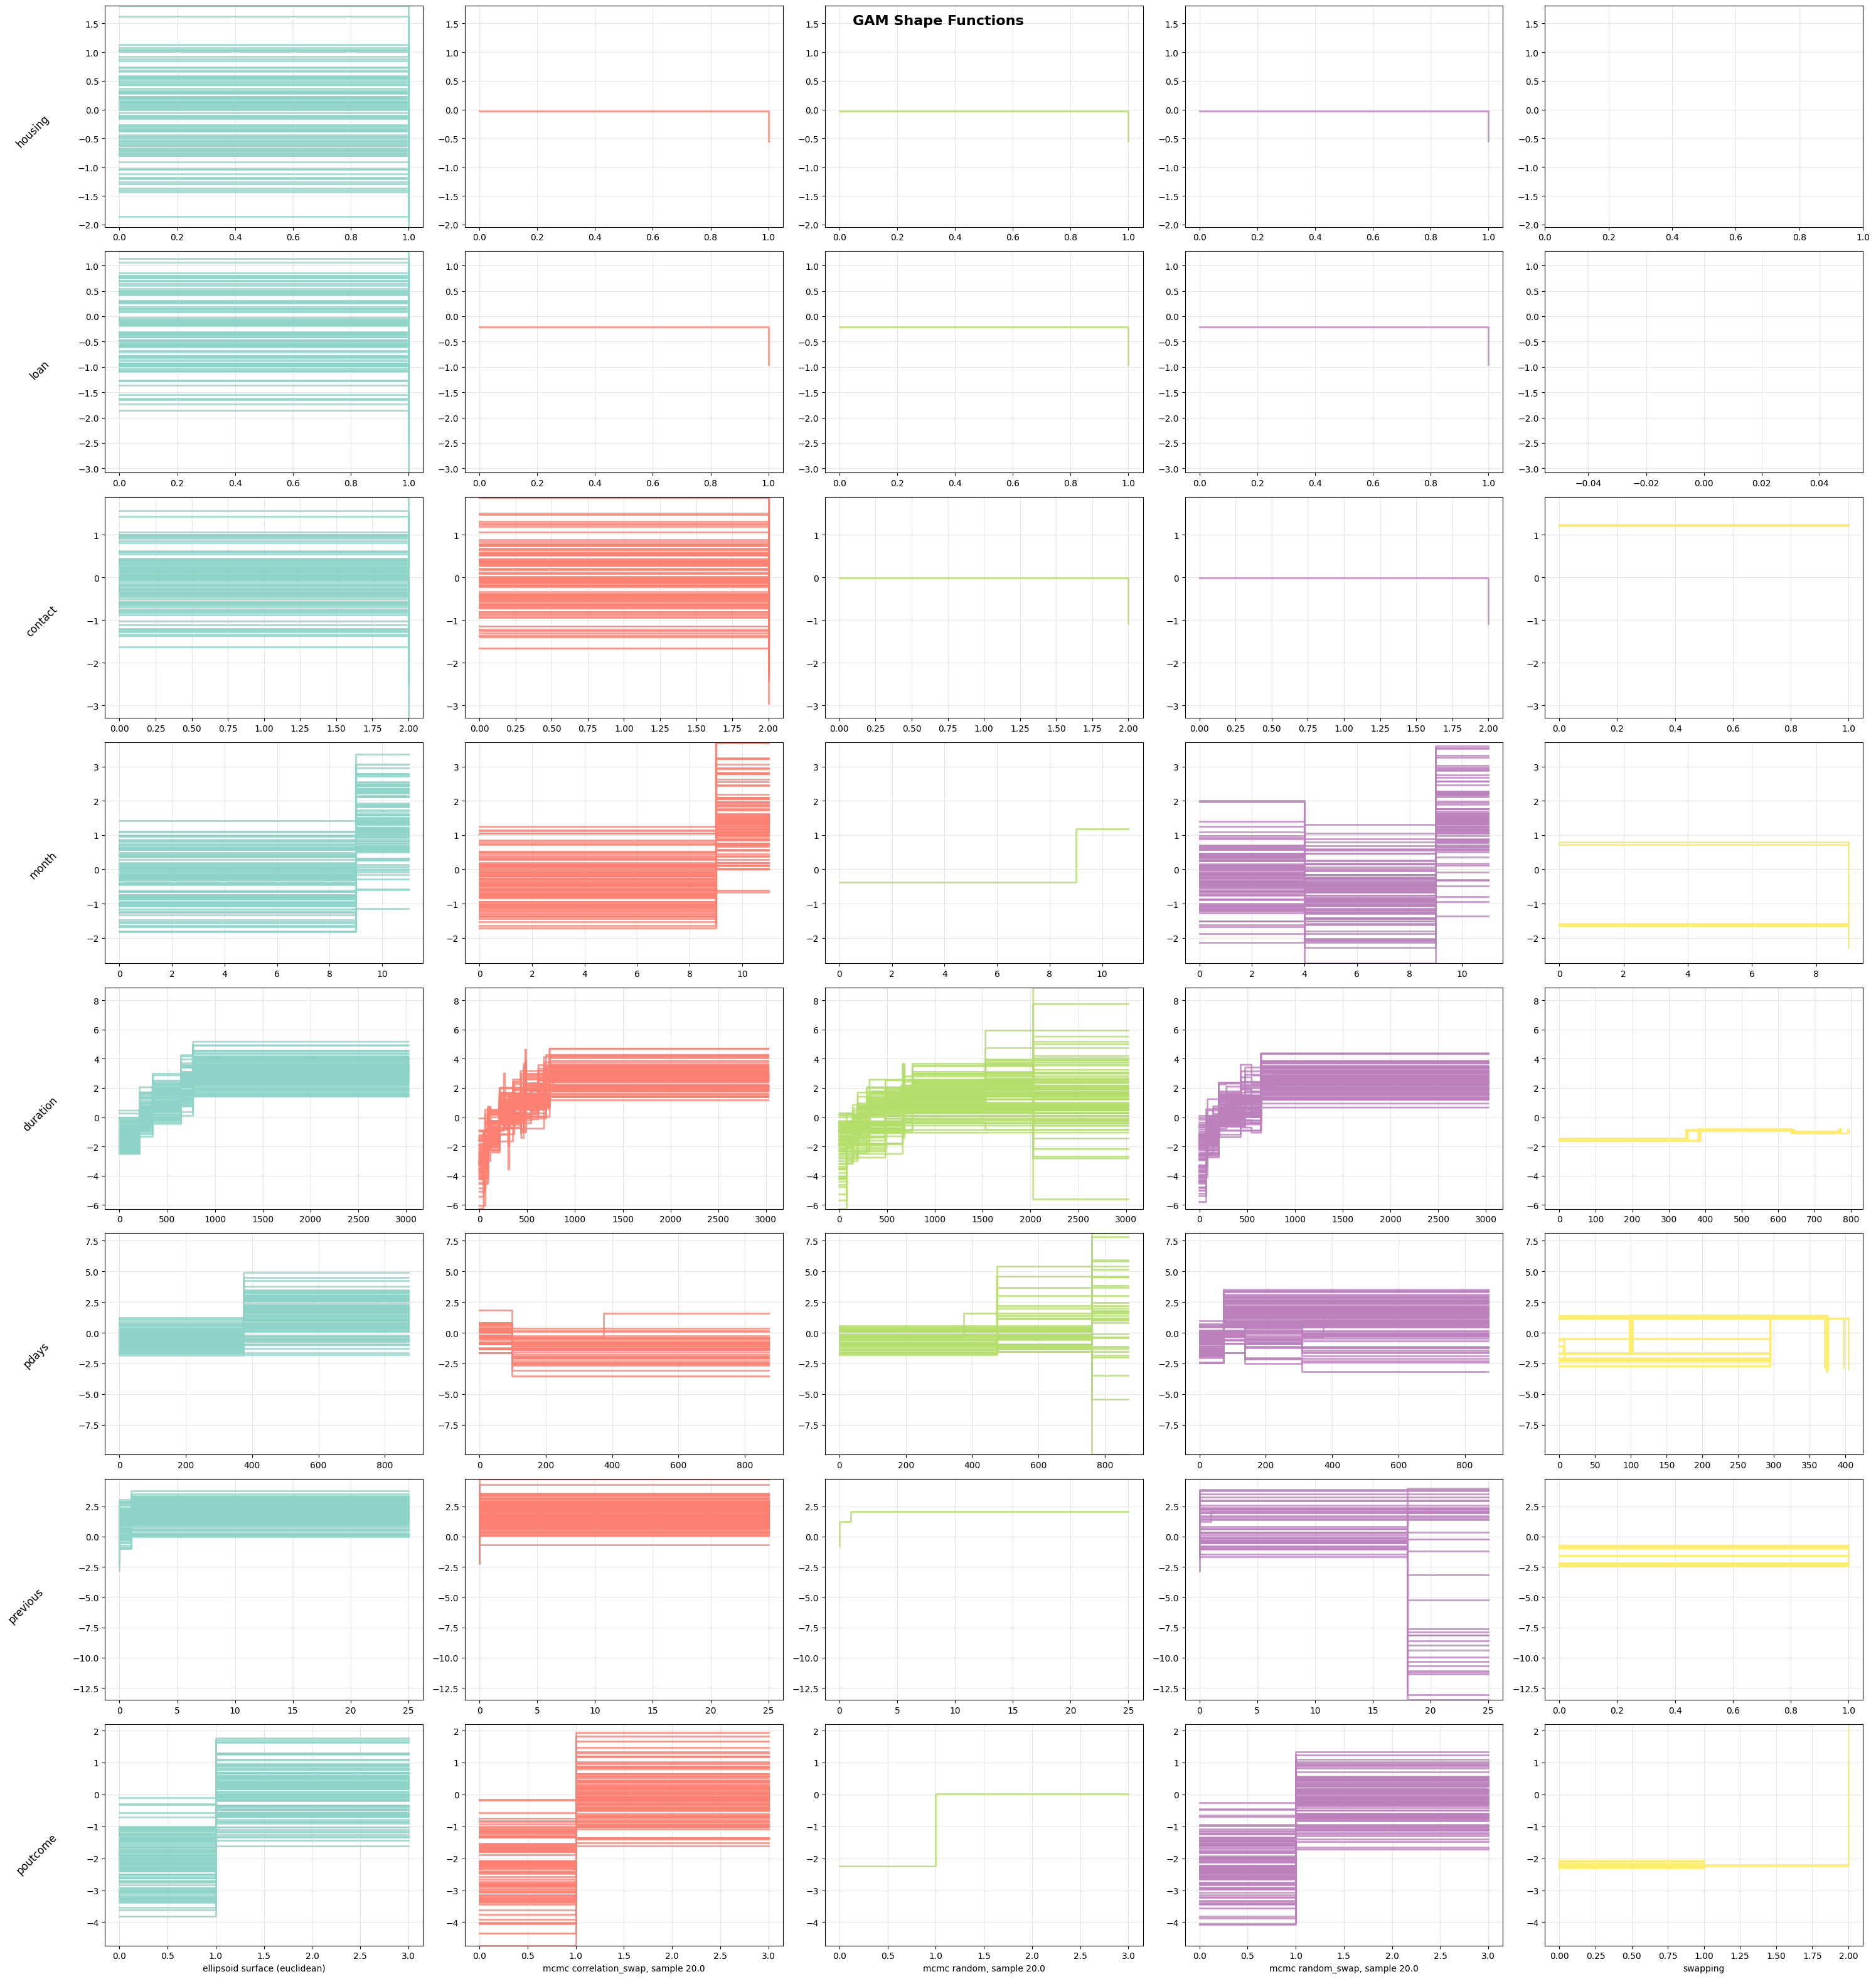

In [59]:
# ["bank", "compas", "diabetes", "spambase", "mimic2"]
gam = get_gam(all_datasets_results, 'bank')

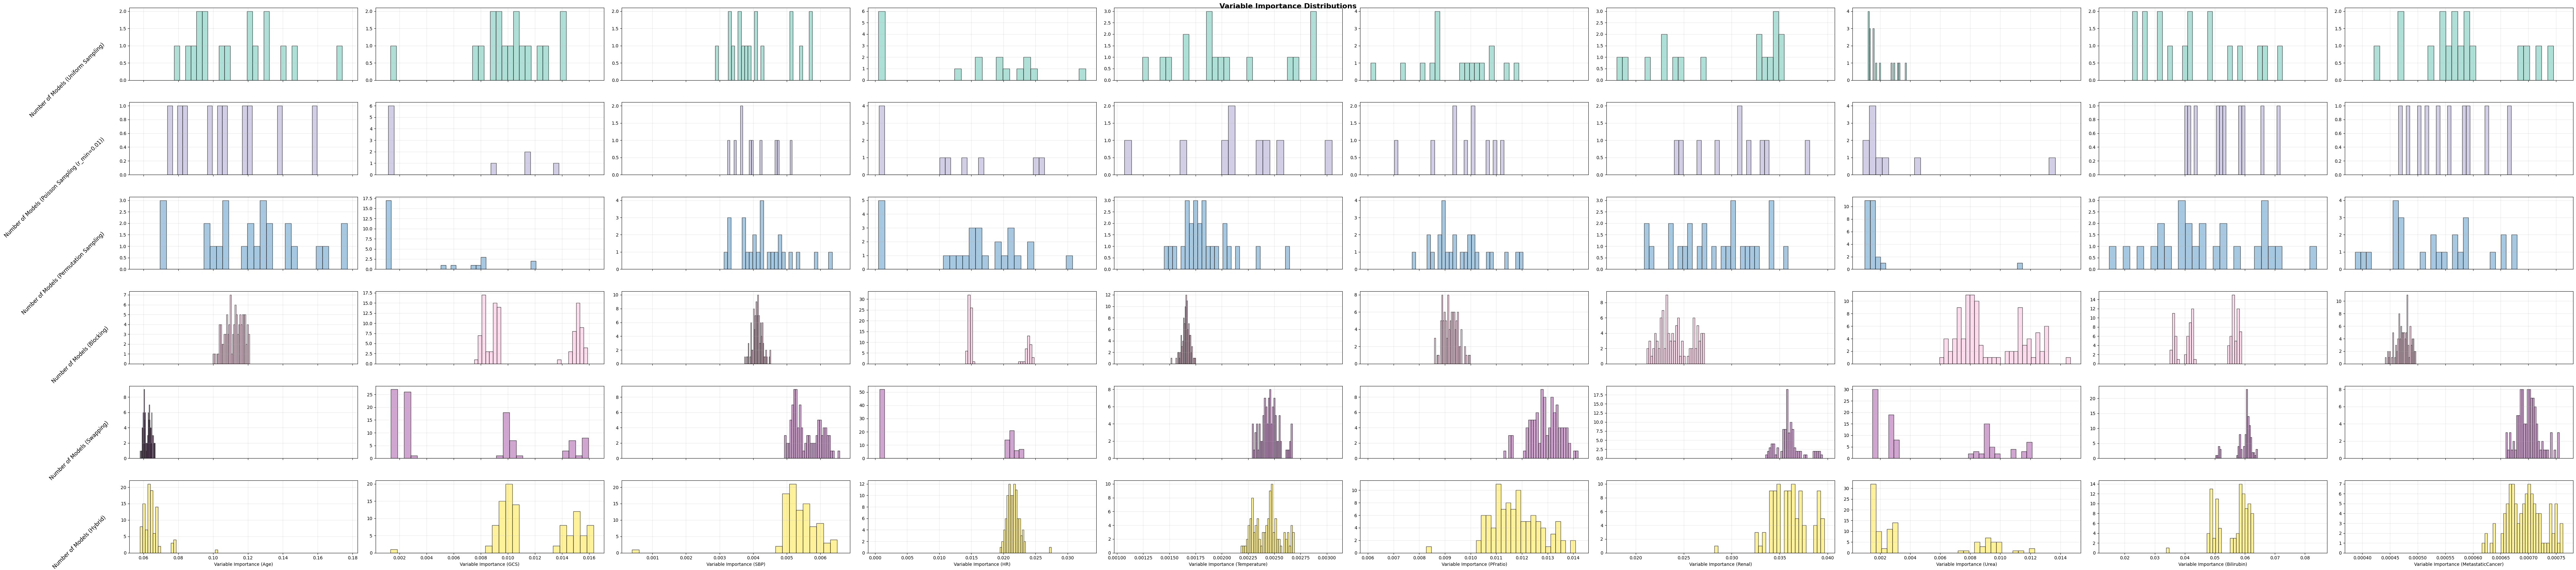

In [7]:
variable_importance = get_variable_importance(all_datasets_results, 'mimic2')

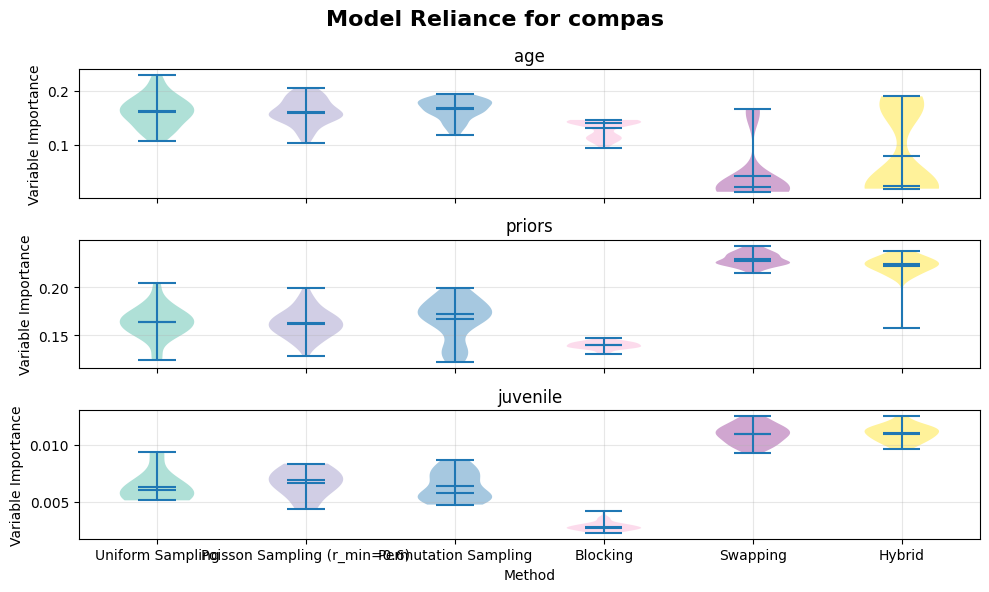

In [24]:
model_reliance = get_model_reliance(all_datasets_results, "compas")

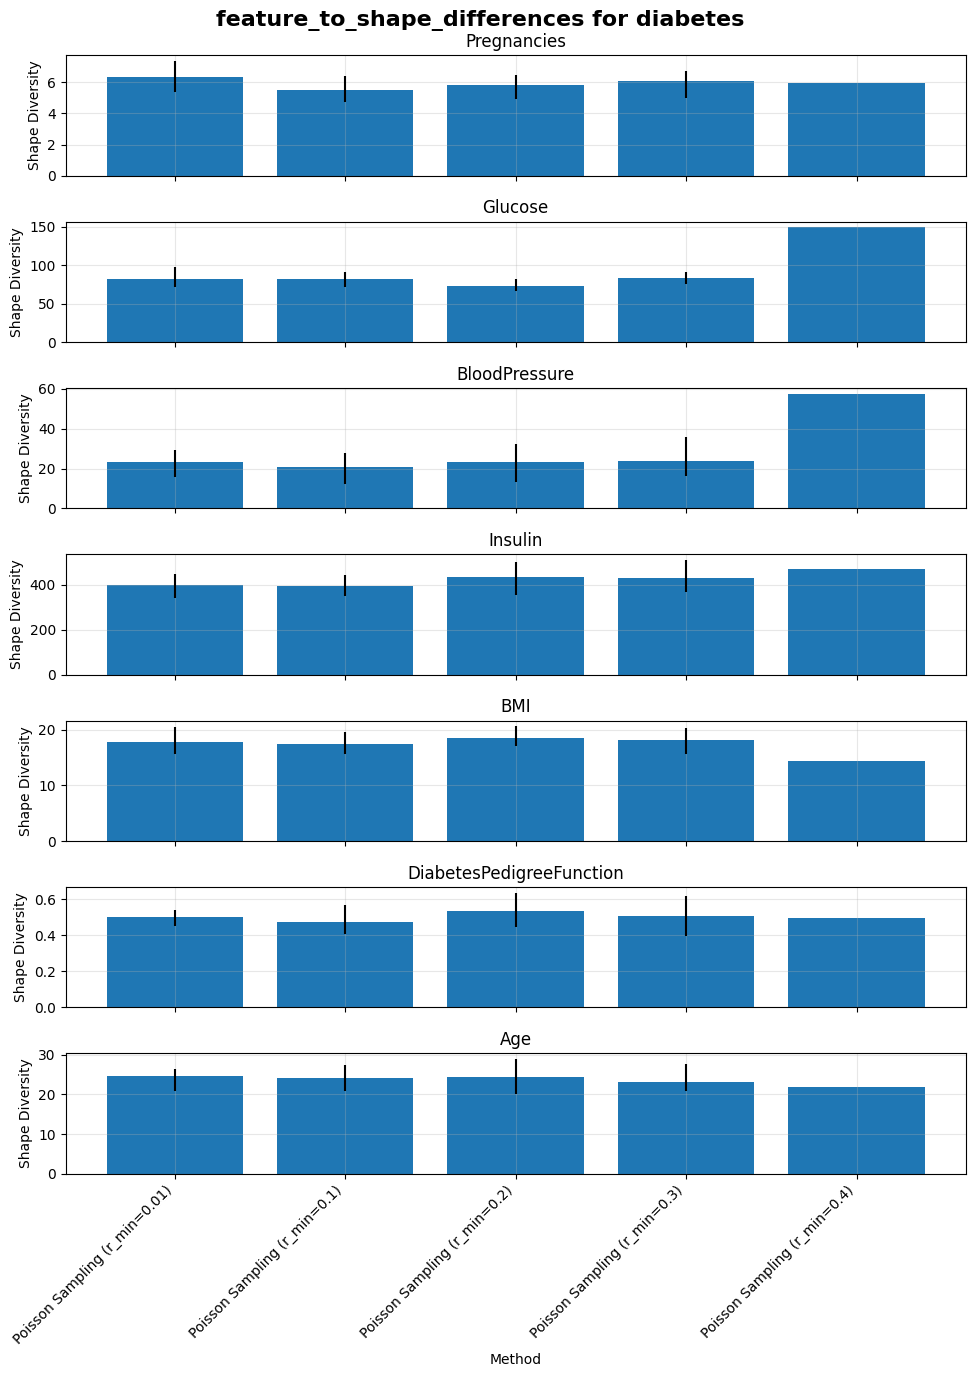

In [ ]:
fsd = get_feature_to_shape_diversity(all_datasets_results, "diabetes", feature_to_shape_metrics[0])

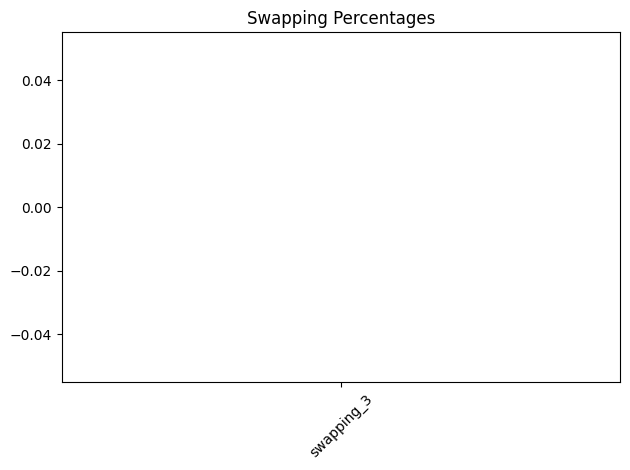

In [ ]:
# show_swapping_percentages(all_datasets_results, "bank")

In [86]:
get_table_results(all_datasets_results)

,dataset,method,accuracy,inverse_IoU,euclidean_distance,inverse_cosine_similarity
0,bank,ellipsoid surface (euclidean),0.098,0.000,35.897,0.175
1,bank,"mcmc correlation_swap, sample 20.0",0.096,0.228,53.108,0.288
2,bank,"mcmc random, sample 20.0",0.096,0.055,71.699,0.594
3,bank,"mcmc random_swap, sample 20.0",0.096,0.017,69.220,0.414
4,compas,ellipsoid surface (euclidean),0.338,0.000,14.628,0.415
5,compas,"mcmc correlation_swap, sample 20.0",0.317,0.088,24.792,0.644
6,compas,"mcmc random, sample 20.0",0.317,0.090,35.505,0.757
7,compas,"mcmc random_swap, sample 20.0",0.317,0.072,26.052,0.584
8,diabetes,ellipsoid surface (euclidean),0.151,0.000,27.499,0.096
9,diabetes,"mcmc correlation_swap, sample 20.0",0.165,0.032,30.219,0.381


In [ ]:
bar_metrics = ['iou', 'euclidean']
for bm in bar_metrics:
    fig = get_bar_plot(all_datasets_results, bm, methods)  # this should create/return the figure
    fig.savefig(f'figures/{bm}_bar_plot.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
for dn in dataset_names:
    fig = get_gam(all_datasets_results, dn)
    fig.savefig(f'figures/{dn}_gam.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
for dn in dataset_names[1:]:
    fig = get_model_reliance(all_datasets_results, dn)
    fig.savefig(f'figures/{dn}_model_reliance.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
for fsd in feature_to_shape_metrics:
    fig = get_feature_to_shape_diversity(all_datasets_results, dn, fsd)
    fig.savefig(f'figures/{fsd}.png', dpi=300, bbox_inches='tight')
    plt.close(fig)